## Risk Measures

The theoretical standard Hungarian university student's daily 95% VaR events are events with a monetary loss equal to the 

daily 95% VaR events are the worst events that happen on average once every twenty days. 

For the theoretical standard Hungarian university student events like that can be spilling food on your shirt during lunch or not waking up in time for an important lecture

yearly 99% VaR events are the worst events that happen on average once every hundred years. So we can think of it as having 100 students and what is the worst event that happens to one of them during the year.
Examples of that can be getting hurt in a car accident or having your laptop stolen

what are the monetary values associated with these events?
To find the monetary value we need to ask ourselves "what is the most amount of money i would pay to avoid having this happen to me" or reversely "what is the least amount of money i would pay to let this event happen to me"

When it comes to spilling food on your shirt and not waking up in time for the lecture it would depend on the severity of the spill, and actually how important was the lecture. But lets assume an "average" severity of these events. Then I think 15 euros would be a reasonable monetary cost of these events.

The cost of your laptop stolen is equal to the cost of having to get a new laptop plus the monetary cost of the burden of being without a laptop until you can replace it. I would estimate this cost to be around 700 euroes, but as laptop prices vary a lot, so will this cost.
The monetary cost of being in a car accident will also depend on severity, so lets assume you get hurt but no lasting injuries. As the average Hungarian university student is not very rich I think they wouldnt pay more than 500 euroes to avoid the accident (given that know there are no lasting injuries)


C:\Users\jonas\AppData\Local\Temp\ipykernel_21592\3929747034.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv(


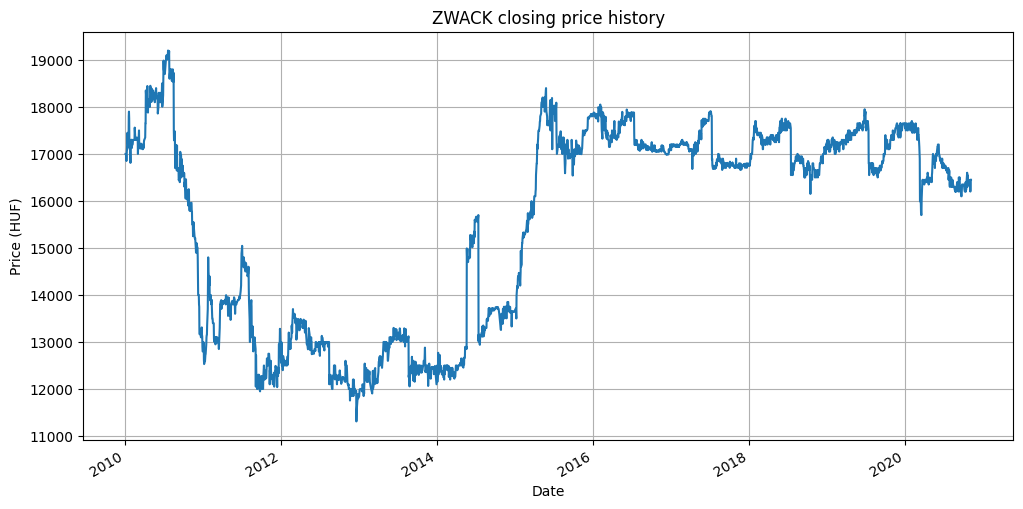

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

data = pd.read_csv(
    'HistoricalPrices.csv',
    parse_dates=['Date'],
    index_col='Date'
)
data = data[[' Close']]
data.rename(columns={' Close': 'Price'}, inplace=True)


data['Price'].plot(figsize=(12, 6), title='ZWACK closing price history')
plt.xlabel('Date')
plt.ylabel('Price (HUF)')
plt.grid()
plt.show()

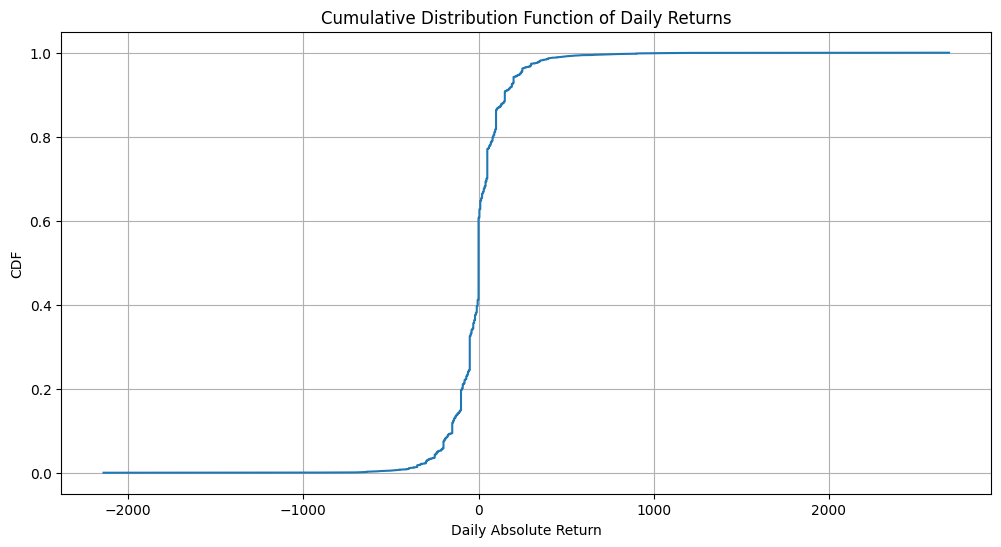

In [32]:

# daily absolute returns
returns = data['Price'].diff().dropna()

# CDF of daily absolute returns
sorted_returns = returns.sort_values()
cdf = np.arange(len(sorted_returns)) / float(len(sorted_returns))


plt.figure(figsize=(12, 6))
plt.plot(sorted_returns.values, cdf)
plt.xlabel('Daily Absolute Return')
plt.ylabel('CDF')
plt.title('Cumulative Distribution Function of Daily Returns')
plt.grid()
plt.show()


In [36]:

# risk measures

# a) standard deviation
std_dev = returns.std()


# b) Lower and upper VaR values at 99% confidence,
percentile_1 = np.percentile(returns, 1)
lower_var_99 = returns[returns < percentile_1].max()
upper_var_99 = returns[returns >= percentile_1].min()

# c) Lower and upper CVaR values at 95% confidence,
cvar_threshold = np.percentile(returns, 5)
lower_cvar_95 = returns[returns < cvar_threshold].mean()
upper_cvar_95 = returns[returns <= cvar_threshold].mean()

#  d) Expected shortfall value at 95% confidence
alpha = 0.95
tail_prob = 1 - alpha
returns_sorted = returns.sort_values()

losses = returns_sorted.values
n = len(losses)
weight = 1/n

es_sum = 0
accumulated = 0

for i in range(n):
    if accumulated + weight <= tail_prob:
        es_sum += losses[i] * weight
        accumulated += weight
    else:
        remaining = tail_prob - accumulated
        es_sum += losses[i] * remaining
        break

es_95 = es_sum / tail_prob


print("Risk Measures:")
print(f"Standard Deviation: {std_dev:.4f}")
print(f"Lower VaR (99% confidence): {lower_var_99:.4f}")
print(f"Upper VaR (99% confidence): {upper_var_99:.4f}")
print(f"Lower CVaR (95% confidence): {lower_cvar_95:.4f}")
print(f"Upper CVaR (95% confidence): {upper_cvar_95:.4f}")
print(f"Expected Shortfall (95% confidence): {es_95:.4f}")


Risk Measures:
Standard Deviation: 165.6444
Lower VaR (99% confidence): -410.0000
Upper VaR (99% confidence): -400.0000
Lower CVaR (95% confidence): -353.7597
Upper CVaR (95% confidence): -348.2593
Expected Shortfall (95% confidence): -353.4248


usefulness of these quantities as risk measures
The standard deviation describes the overall volatility, but does not distiguish between positive and negative returns, the number itself can also be hard to interpret as it isnt a dollar value, unlike VaR
The VaR tells us the worst loss inside some given confidence interval (99% in this case), meaning the worst loss we will see no less than once every hundred days is 400.
The CVaR is the expected loss given that we are on the left side of the confidence interval. In this we expect a loss of 353 given given that in of the 5% worst days
The expected shortfall is always between the lower and upper CVaR and will therefore give us pretty much the same information. But ES is coherent, which the other risk measures are not, which means ES satisfies the coherence axioms 